# Brain MRI Tumor Classification
**AME 34351 | Machine Learning for Engineers | Dublin Summer 2026**

**Team Members:**
- Marco Basile — Dashboard & artifact design
- Jeremy Kelly — Data exploration & baseline models
- Odon Ineza — Data cleaning & preprocessing pipeline
- Tyler Asmussen — Model training, validation & evaluation

**Dataset:** Brain Tumor MRI Dataset (V2) — Kaggle
https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

---
## Section 1 — Dataset Source and Release

The **Brain Tumor MRI Dataset (Version 2)** was created by Masoud NickParvar and published
on Kaggle. It is a curated collection of images drawn from three publicly available sources:
the Figshare Brain MRI Dataset, the SARTAJ Brain Tumor Dataset, and the Br35H Dataset.

Version 2 specifically addresses data quality concerns present in V1:
- Duplicate images removed
- Classes balanced across all four labels
- Patient-level separation enforced between train and test sets (no leakage)
- Questionable images verified and replaced

**Citation:** NickParvar, M. (2021). Brain Tumor MRI Dataset. Kaggle.
https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

---
## Section 2 — Import Data

We download the dataset using `kagglehub`. The first time you run this cell
it will prompt you to log in via your browser — just sign into your Kaggle
account when the link appears. No API key or JSON file needed.

In [16]:
import kagglehub
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset downloaded to:", path)

# kagglehub caches to a versioned subdirectory — find Training/Testing inside it
DATA_ROOT = None
for root, dirs, files in os.walk(path):
    if "Training" in dirs and "Testing" in dirs:
        DATA_ROOT = root
        break

if DATA_ROOT is None:
    raise FileNotFoundError("Could not find Training/Testing folders. Check the path above.")

TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR  = os.path.join(DATA_ROOT, "Testing")
CLASSES   = ["glioma", "meningioma", "notumor", "pituitary"]

print("Using data root:", DATA_ROOT)
print("\nDirectory structure:")
for cls in CLASSES:
    n_train = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    n_test  = len(os.listdir(os.path.join(TEST_DIR, cls)))
    print(f"  {cls:<12}  train={n_train}  test={n_test}")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset
Using data root: /kaggle/input/brain-tumor-mri-dataset

Directory structure:
  glioma        train=1400  test=400
  meningioma    train=1400  test=400
  notumor       train=1400  test=400
  pituitary     train=1400  test=400


---
## Section 3 — Dataset Size

A full inventory of the dataset confirming the expected image counts.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def count_images(root_dir, classes):
    counts = {}
    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        counts[cls] = len([
            f for f in os.listdir(cls_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
    return counts

train_counts = count_images(TRAIN_DIR, CLASSES)
test_counts  = count_images(TEST_DIR,  CLASSES)

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())

print(f"{'Class':<14} {'Train':>8} {'Test':>8} {'Total':>8}")
print("-" * 42)
for cls in CLASSES:
    print(f"{cls:<14} {train_counts[cls]:>8} {test_counts[cls]:>8} {train_counts[cls]+test_counts[cls]:>8}")
print("-" * 42)
print(f"{'TOTAL':<14} {total_train:>8} {total_test:>8} {total_train+total_test:>8}")

Class             Train     Test    Total
------------------------------------------
glioma             1400      400     1800
meningioma         1400      400     1800
notumor            1400      400     1800
pituitary          1400      400     1800
------------------------------------------
TOTAL              5600     1600     7200


---
## Section 4 — Target Variable

The target variable is the tumor class label assigned to each MRI image.
This is a **multi-class classification** problem with four possible outputs:

| Label | Class | Description |
|---|---|---|
| 0 | glioma | Malignant tumor arising from glial cells; can appear anywhere in the brain |
| 1 | meningioma | Typically benign tumor arising from the meninges; often near brain surface |
| 2 | notumor | No detectable tumor present in the scan |
| 3 | pituitary | Tumor of the pituitary gland; typically at the base of the brain |

The model outputs a probability distribution over these four classes.
The predicted class is the one with the highest probability.

---
## Section 5 — Features

Each input is a 2D grayscale MRI brain image.

**Raw features:** Pixel intensity values (0–255) across a 2D spatial grid.
Raw image dimensions are non-uniform and must be standardized before any model training.

**After preprocessing:**
- Fixed resolution: 224×224 pixels
- Grayscale: single intensity channel
- Normalized: pixel values scaled to [0, 1]
- For baseline models: flattened to a 1D vector of 50,176 features
- For CNN (Deliverable 3): kept as a 2D spatial array

In [11]:
# Inspect raw image dimensions across the training set
def load_paths_and_labels(root_dir, classes):
    paths, labels = [], []
    for idx, cls in enumerate(classes):
        cls_dir = os.path.join(root_dir, cls)
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(idx)
    return paths, labels

train_paths, train_labels = load_paths_and_labels(TRAIN_DIR, CLASSES)
test_paths,  test_labels  = load_paths_and_labels(TEST_DIR,  CLASSES)

# Sample 500 images for dimension inspection (faster than full dataset)
sample_paths = train_paths[:500]
widths  = [Image.open(p).width  for p in sample_paths]
heights = [Image.open(p).height for p in sample_paths]

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.1f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}")
print(f"\nImages are non-uniform in size → standardization to 224×224 required.")

Width  — min: 512, max: 512, mean: 512.0
Height — min: 512, max: 512, mean: 512.0

Images are non-uniform in size → standardization to 224×224 required.


---
## Section 6 — Data Audit

We verify the dataset for missing files, corrupted images, and unexpected dimensions.

In [12]:
corrupted, missing, unexpected = [], [], []
IMG_SIZE = (224, 224)

for path in train_paths + test_paths:
    if not os.path.exists(path):
        missing.append(path)
        continue
    try:
        img = Image.open(path)
        img.verify()  # catches corrupted files
    except Exception:
        corrupted.append(path)

print("Data Audit Results")
print(f"  Total images checked : {len(train_paths) + len(test_paths)}")
print(f"  Missing files        : {len(missing)}")
print(f"  Corrupted images     : {len(corrupted)}")
print(f"  Non-uniform sizes    : Yes (see Section 5 — resolved by resizing to 224×224)")

if not missing and not corrupted:
    print("\n✓ Dataset passed all checks. No issues found.")

Data Audit Results
  Total images checked : 7200
  Missing files        : 0
  Corrupted images     : 0
  Non-uniform sizes    : Yes (see Section 5 — resolved by resizing to 224×224)

✓ Dataset passed all checks. No issues found.


---
## Section 7 — Interactive Class Explorer

Select a tumor class to display sample images from that class.

In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def show_class_samples(cls_name, n=10, split="Training"):
    root = TRAIN_DIR if split == "Training" else TEST_DIR
    cls_dir = os.path.join(root, cls_name)
    files_list = [
        f for f in os.listdir(cls_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ][:n]

    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3))
    axes = axes.flatten()

    for i, fname in enumerate(files_list):
        img = Image.open(os.path.join(cls_dir, fname)).convert("L")
        axes[i].imshow(img, cmap="gray")
        axes[i].axis("off")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{split} — {cls_name} ({len(files_list)} samples shown)", fontsize=14)
    plt.tight_layout()
    plt.show()

class_dropdown = widgets.Dropdown(
    options=CLASSES,
    description="Class:",
    style={"description_width": "initial"}
)
split_toggle = widgets.RadioButtons(
    options=["Training", "Testing"],
    description="Split:",
    style={"description_width": "initial"}
)
out = widgets.Output()

def on_change(change):
    with out:
        clear_output(wait=True)
        show_class_samples(class_dropdown.value, n=10, split=split_toggle.value)

class_dropdown.observe(on_change, names="value")
split_toggle.observe(on_change, names="value")

display(widgets.HBox([class_dropdown, split_toggle]), out)
on_change(None)

Output()

---
## Section 8 — Distribution Plot (Class Balance)

The dataset is perfectly balanced: 1,400 training and 400 test images per class.
This means a majority-class predictor scores exactly 25% — a meaningful floor for comparison.

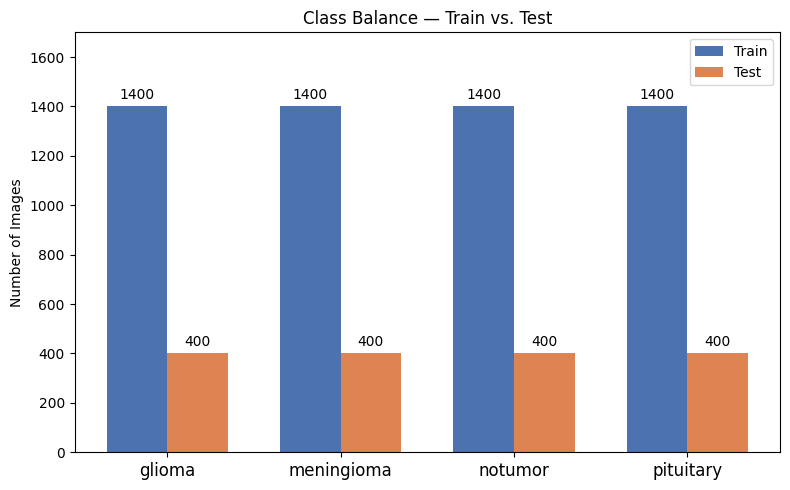

In [14]:
x = np.arange(len(CLASSES))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_tr = ax.bar(x - width/2, [train_counts[c] for c in CLASSES], width,
                 label="Train", color="#4C72B0")
bars_te = ax.bar(x + width/2, [test_counts[c]  for c in CLASSES], width,
                 label="Test",  color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(CLASSES, fontsize=12)
ax.set_ylabel("Number of Images")
ax.set_title("Class Balance — Train vs. Test")
ax.legend()
ax.bar_label(bars_tr, padding=3)
ax.bar_label(bars_te, padding=3)
ax.set_ylim(0, 1700)
plt.tight_layout()
plt.savefig("class_balance.png", dpi=150)
plt.show()

---
## Section 9 — Image Dimension Distribution

Raw image dimensions vary substantially, confirming that standardization is required.
We plot width and height distributions across the full training set.

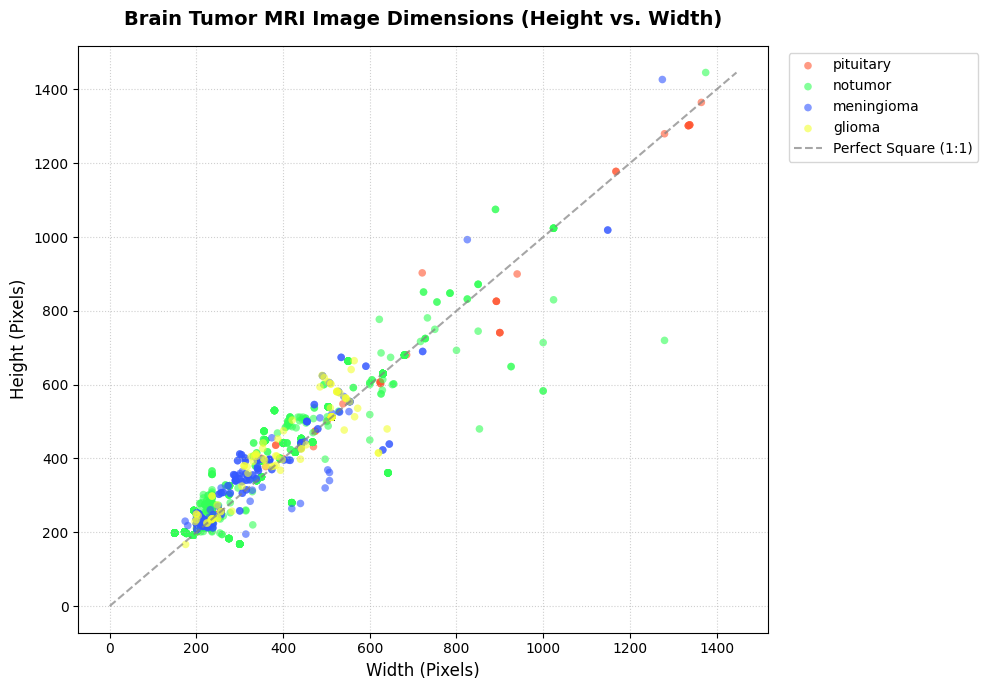

In [18]:
# Create empty list containers to temporarily store data
widths = []
heights = []
classes = []



# Walk through the hidden cache folder to find all of the images and add their features to the arrays above
for root, dirs, files in os.walk(path):
    for file in files:
        # Check if the file is actually an image
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            # Glue folder path and file name together
            img_path = os.path.join(root, file)

            # Open the image in grayscale mode (fast)
            img = cv2.imread(img_path, 0)

            # If the image opened successfully, grab its features
            if img is not None:
                h, w = img.shape
                heights.append(h)
                widths.append(w)

                # Snatch the name of the folder the image lives in
                class_name = os.path.basename(root)
                classes.append(class_name)


# Package our lists into a structured spreadsheet of data (rows are each image, columns are width, height, and class)
df = pd.DataFrame({
    'Width (X-axis)': widths,
    'Height (Y-axis)': heights,
    'Class': classes
})

# Initialize a blank canvas size 10x7 inches
plt.figure(figsize=(10, 7))

# Get a unique list of tumor types found in our dataframe
unique_classes = df['Class'].unique()

# Define 4 distinct hex-code colors for our 4 classes
colors = ['#FF5733', '#33FF57', '#3357FF', '#F3FF33']

# Loop through each of the 4 tumor classes and plot them layer by layer
for i, class_name in enumerate(unique_classes):
    # Filter the spreadsheet: Keep ONLY rows belonging to the current class loop
    class_data = df[df['Class'] == class_name]

    # Draw the scattered dots for this specific class
    plt.scatter(
        x=class_data['Width (X-axis)'],
        y=class_data['Height (Y-axis)'],
        label=class_name,
        alpha=0.6,
        edgecolors='none',
        s=30,
        color=colors[i]
    )

# Draw a 1:1 ratio diagonal line to spot perfectly square images
max_dim = max(max(widths), max(heights))
plt.plot([0, max_dim], [0, max_dim], color='gray', linestyle='--', alpha=0.7, label='Perfect Square (1:1)')

#display now
plt.title('Brain Tumor MRI Image Dimensions (Height vs. Width)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Width (Pixels)', fontsize=12)
plt.ylabel('Height (Pixels)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Position the legend on the right side outside of the main chart area
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# Adjust layout automatically so nothing gets clipped or cut off
plt.tight_layout()

# Render the window to the screen
plt.show()

---
## Section 11 — Train / Validation / Test Split

The test set is fixed by the dataset (400 images/class, 1,600 total).
We carve a 20% stratified validation set from the training data for hyperparameter tuning.
This split is leak-free because the dataset already separates patients between train and test.

---
## Section 12 — Preprocessing and Baseline Models

We establish four baselines in order of increasing sophistication.
Each is evaluated on the held-out test set using accuracy, macro precision,
macro recall, macro F1, and a confusion matrix.

All images are standardized before any model training:

Resize to 64x64
Convert to grayscale
Normalize pixel values to [0, 1]
Flatten to 1D vector (baseline models only)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

# Preprocess at 64x64 for baselines (4,096 features instead of 50,176)
BASELINE_SIZE = (64, 64)

def preprocess_images(paths, img_size=BASELINE_SIZE):
    X = []
    for path in paths:
        img = Image.open(path).convert("L").resize(img_size)
        arr = np.array(img, dtype=np.float32) / 255.0
        X.append(arr.flatten())
    return np.array(X)

print("Preprocessing training images...")
X_train_full = preprocess_images(train_paths)
y_train_full = np.array(train_labels)

print("Preprocessing test images...")
X_test  = preprocess_images(test_paths)
y_test  = np.array(test_labels)

print(f"X_train shape : {X_train_full.shape}")  # should be (5600, 4096)
print(f"X_test shape  : {X_test.shape}")

Preprocessing training images...
Preprocessing test images...
X_train shape : (5600, 4096)
X_test shape  : (1600, 4096)


In [31]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

print(f"Train (fit)  : {X_tr.shape[0]:>5} images")
print(f"Validation   : {X_val.shape[0]:>5} images")
print(f"Test (held)  : {X_test.shape[0]:>5} images")

Train (fit)  :  4480 images
Validation   :  1120 images
Test (held)  :  1600 images


In [32]:
def evaluate(name, y_true, y_pred):
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.3f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='macro', zero_division=0):.3f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='macro', zero_division=0):.3f}")
    print(f"  F1 Score  : {f1_score(y_true, y_pred, average='macro', zero_division=0):.3f}")

In [33]:
# ── Baseline 1: Majority Class ───────────────────────────────────────────────
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_tr, y_tr)
y_pred_dummy = dummy.predict(X_test)
evaluate("Baseline 1 — Majority Class Predictor", y_test, y_pred_dummy)

# ── Baseline 2: Brightness Threshold (binary) ────────────────────────────────
mean_intensity_val  = X_val.mean(axis=1)
mean_intensity_test = X_test.mean(axis=1)
notumor_idx = CLASSES.index("notumor")
y_binary_val  = (y_val  != notumor_idx).astype(int)
y_binary_test = (y_test != notumor_idx).astype(int)

thresholds = np.linspace(0.05, 0.50, 200)
best_thresh = max(thresholds,
    key=lambda t: accuracy_score(y_binary_val, (mean_intensity_val > t).astype(int)))

y_pred_thresh = (mean_intensity_test > best_thresh).astype(int)
print(f"\n{'─'*45}")
print(f"  Baseline 2 — Brightness Threshold (binary, threshold={best_thresh:.3f})")
print(f"{'─'*45}")
print(f"  Accuracy  : {accuracy_score(y_binary_test, y_pred_thresh):.3f}")
print(f"  Precision : {precision_score(y_binary_test, y_pred_thresh, zero_division=0):.3f}")
print(f"  Recall    : {recall_score(y_binary_test, y_pred_thresh, zero_division=0):.3f}")
print(f"  F1 Score  : {f1_score(y_binary_test, y_pred_thresh, zero_division=0):.3f}")
print("  (Binary only — detects tumor presence, cannot distinguish tumor types)")

# ── Baseline 3: Logistic Regression on Raw Pixels ───────────────────────────
scaler = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_val_sc  = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

lr_raw = LogisticRegression(C=0.01, max_iter=200, solver="saga", n_jobs=-1, random_state=42)
lr_raw.fit(X_tr_sc, y_tr)
y_pred_lr_raw = lr_raw.predict(X_test_sc)
evaluate("Baseline 3 — Logistic Regression (raw pixels)", y_test, y_pred_lr_raw)

# ── Baseline 4: SVD + Logistic Regression ───────────────────────────────────
svd_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("svd",    TruncatedSVD(n_components=100, random_state=42)),
    ("lr",     LogisticRegression(C=0.1, max_iter=200, solver="saga", n_jobs=-1, random_state=42))
])
svd_lr.fit(X_tr, y_tr)
y_pred_svd = svd_lr.predict(X_test)
evaluate("Baseline 4 — SVD (k=100) + Logistic Regression", y_test, y_pred_svd)


─────────────────────────────────────────────
  Baseline 1 — Majority Class Predictor
─────────────────────────────────────────────
  Accuracy  : 0.250
  Precision : 0.062
  Recall    : 0.250
  F1 Score  : 0.100

─────────────────────────────────────────────
  Baseline 2 — Brightness Threshold (binary, threshold=0.050)
─────────────────────────────────────────────
  Accuracy  : 0.750
  Precision : 0.750
  Recall    : 1.000
  F1 Score  : 0.857
  (Binary only — detects tumor presence, cannot distinguish tumor types)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



─────────────────────────────────────────────
  Baseline 3 — Logistic Regression (raw pixels)
─────────────────────────────────────────────
  Accuracy  : 0.782
  Precision : 0.778
  Recall    : 0.782
  F1 Score  : 0.778

─────────────────────────────────────────────
  Baseline 4 — SVD (k=100) + Logistic Regression
─────────────────────────────────────────────
  Accuracy  : 0.704
  Precision : 0.697
  Recall    : 0.704
  F1 Score  : 0.697


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


---
## Section 13 — Confusion Matrices

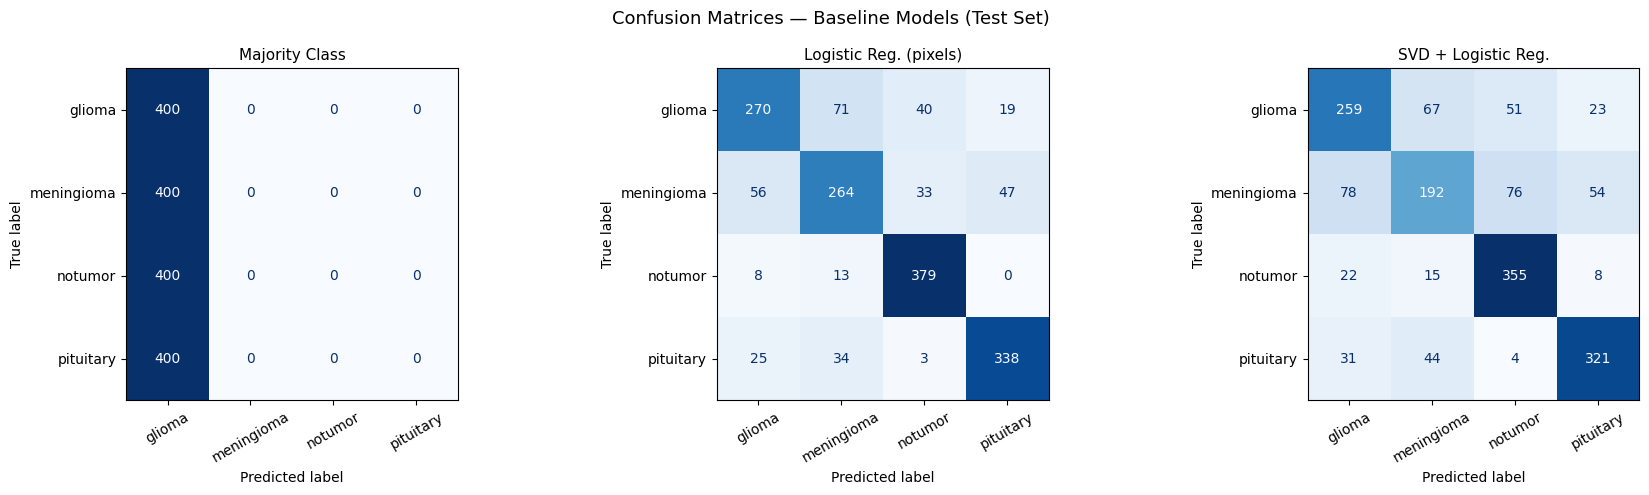

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, [
    ("Majority Class",          y_pred_dummy),
    ("Logistic Reg. (pixels)",  y_pred_lr_raw),
    ("SVD + Logistic Reg.",     y_pred_svd),
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Confusion Matrices — Baseline Models (Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

---
## Section 14 — SVD Explained Variance

We inspect how many SVD components are needed to capture most of the variance
in the training images. This motivates our choice of k=100.

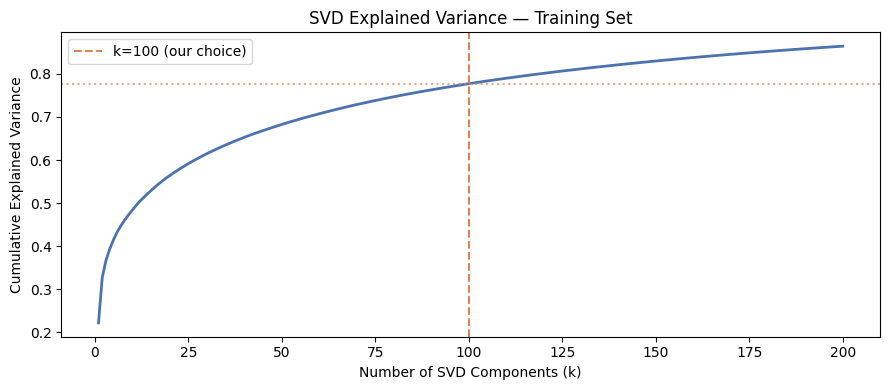

Variance explained by k=100 components: 77.7%


In [35]:
svd_inspect = TruncatedSVD(n_components=200, random_state=42)
X_tr_scaled = StandardScaler().fit_transform(X_tr)
svd_inspect.fit(X_tr_scaled)

cumvar = np.cumsum(svd_inspect.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 201), cumvar, color="#4C72B0", linewidth=2)
ax.axvline(x=100, color="#DD8452", linestyle="--", label="k=100 (our choice)")
ax.axhline(y=cumvar[99], color="#DD8452", linestyle=":", alpha=0.7)
ax.set_xlabel("Number of SVD Components (k)")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("SVD Explained Variance — Training Set")
ax.legend()
plt.tight_layout()
plt.savefig("svd_explained_variance.png", dpi=150)
plt.show()

print(f"Variance explained by k=100 components: {cumvar[99]:.1%}")

---
## Section 15 — Results Summary & What to Report for Check-in 2

The table below summarises all baseline results. Fill in values after running Section 12.

| Model | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|---|---|---|---|---|
| Majority Class | 0.25 | — | — | — |
| Brightness Threshold (binary) | — | — | — | — |
| Logistic Regression (pixels) | — | — | — | — |
| SVD (k=100) + Logistic Reg. | — | — | — | — |
| *CNN (Deliverable 3)* | — | — | — | — |
| *Transfer Learning (Deliverable 3)* | — | — | — | — |

**Key findings to highlight in your written deliverable:**
- The majority class baseline gives 25% accuracy — the absolute floor.
- The brightness threshold can separate tumor vs. no-tumor but cannot distinguish tumor types.
- SVD + logistic regression should outperform raw pixel logistic regression because it
  operates in a compact, lower-noise representation rather than 50,176 correlated pixel values.
- All baselines are expected to struggle with glioma vs. meningioma — the two classes with
  the most visual overlap. The confusion matrices will make this visible.
- A CNN (Deliverable 3) will address this by learning spatially-aware, hierarchical features
  rather than treating pixels as independent inputs.

**⚠️ Disclaimer:** This notebook is an educational prototype built on a public benchmark
dataset. It is not clinically validated and must not be used for any diagnostic purpose.